# 🔍 Telco Churn: Exploratory Data Analysis (EDA)

**Objective**: Understand the dataset, identify patterns, and generate insights for churn prediction

**Key Questions**:
- What is the churn rate and class distribution?
- Which features correlate most strongly with churn?
- Are there missing values or data quality issues?
- What feature engineering opportunities exist?
- Are there segment-specific churn patterns?

**Output**: Visualizations, summary statistics, and actionable insights for modeling

---
*Run from project root with activated environment*

## 1. Setup & Imports

In [1]:
# === 1. Setup & Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys

# Project setup
project_root = Path.cwd().parent.parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import settings
from src.data.validation import validate_data_quality

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

print(f"✅ Environment ready | Pandas: {pd.__version__} | Seaborn: {sns.__version__}")

✅ Environment ready | Pandas: 2.3.3 | Seaborn: 0.13.2


## 2. Load & Overview Data

In [2]:
# === 2. Load Data ===
data_paths = [
    Path('..', '..', 'data', 'raw', 'telco.csv'),
    Path('..', 'data', 'raw', 'telco.csv'),
    Path('data', 'raw', 'telco.csv'),
    Path('telco.csv')
]

data_file = next((p for p in data_paths if p.exists()), None)
if data_file is None:
    raise FileNotFoundError("telco.csv not found. Please place in data/raw/")

print(f"📁 Loading data from: {data_file}")
df = pd.read_csv(data_file)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

📁 Loading data from: ..\..\data\raw\telco.csv
✅ Loaded: 7,043 rows × 50 columns


In [3]:
# === 2.1 Basic Info ===
print("\n📋 Dataset Overview:")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Duplicate rows: {df.duplicated().sum()}")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"\n📊 Column Types:")
print(df.dtypes.value_counts())


📋 Dataset Overview:
   Memory usage: 11.92 MB
   Duplicate rows: 0
   Missing values: 15751

📊 Column Types:
object     31
int64      11
float64     8
Name: count, dtype: int64


In [4]:
# === 2.2 Preview Data ===
print("\n🔍 First 5 rows:")
display(df.head())

print("\n🔍 Sample random rows:")
display(df.sample(5, random_state=42))


🔍 First 5 rows:


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges



🔍 Sample random rows:


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
185,1732-VHUBQ,Female,73,No,Yes,Yes,No,0,United States,California,...,0,1266.65,4548.91,3,Churned,Yes,82,4457,Competitor,Competitor made better offer
2715,6292-TOSSS,Male,64,No,No,No,No,0,United States,California,...,0,2358.00,3553.25,4,Stayed,No,68,4297,NaN,NaN
3825,2546-KZAAT,Male,28,Yes,No,Yes,No,0,United States,California,...,0,540.80,4406.25,5,Stayed,No,59,5211,NaN,NaN
1807,4946-EDSEW,Female,35,No,No,Yes,Yes,3,United States,California,...,0,319.11,499.41,1,Churned,Yes,69,5638,Attitude,Attitude of support person
132,9061-TIHDA,Male,67,No,Yes,Yes,No,0,United States,California,...,0,412.10,1597.66,1,Churned,Yes,90,2982,Competitor,Competitor had better devices


## 3. Data Quality Assessment

⚠️  Columns with missing values:


,Missing Count,Missing %
Churn Reason,5174,73.46
Churn Category,5174,73.46
Offer,3877,55.05
Internet Type,1526,21.67


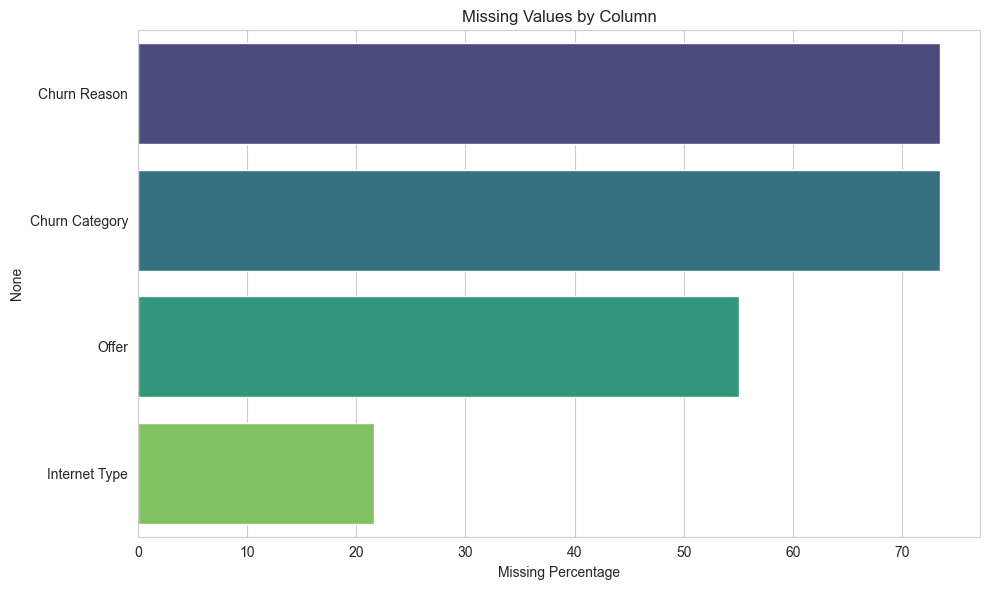

In [5]:
# === 3.1 Missing Values Analysis ===
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("⚠️  Columns with missing values:")
    display(missing_df)
else:
    print("✅ No missing values found")

# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_df['Missing %'], y=missing_df.index, palette='viridis')
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig(project_root / settings.artifacts_path / 'eda_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()

In [6]:
# === 3.2 Data Quality Report ===
quality_report = validate_data_quality(df)

print("\n📋 Data Quality Report:")
for key, value in quality_report.items():
    print(f"   {key}: {value}")

if quality_report['quality_score'] >= 90:
    print("\n✅ Excellent data quality - ready for modeling")
elif quality_report['quality_score'] >= 80:
    print("\n⚠️  Good data quality - minor cleaning may help")
else:
    print("\n❌ Low data quality - consider data cleaning before modeling")


📋 Data Quality Report:
   total_rows: 7043
   total_columns: 50
   missing_cells: 15751
   missing_percentage: 4.47
   duplicate_rows: 0
   duplicate_percentage: 0.0
   quality_score: 95.5

✅ Excellent data quality - ready for modeling


In [7]:
# === 3.3 Unique Values & Cardinality ===
print("\n🔢 Unique Values per Column:")
unique_counts = df.nunique().sort_values(ascending=False)
display(unique_counts.head(20))

# Identify high-cardinality categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
high_cardinality = [col for col in categorical_cols if df[col].nunique() > 20 and df[col].nunique() < len(df) * 0.5]

if high_cardinality:
    print(f"\n⚠️  High-cardinality categorical columns (may need encoding):")
    print(high_cardinality)


🔢 Unique Values per Column:


Customer ID                          7043
Total Revenue                        6982
Total Charges                        6540
Total Long Distance Charges          6087
Avg Monthly Long Distance Charges    3584
CLTV                                 3438
Zip Code                             1626
Latitude                             1626
Longitude                            1625
Monthly Charge                       1585
Population                           1569
City                                 1106
Total Refunds                         500
Churn Score                            81
Tenure in Months                       72
Age                                    62
Avg Monthly GB Download                50
Churn Reason                           20
Total Extra Data Charges               16
Number of Referrals                    12
dtype: int64


⚠️  High-cardinality categorical columns (may need encoding):
['City']


## 4. Target Variable Analysis


🎯 Target Variable: Churn Label

Value Counts:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


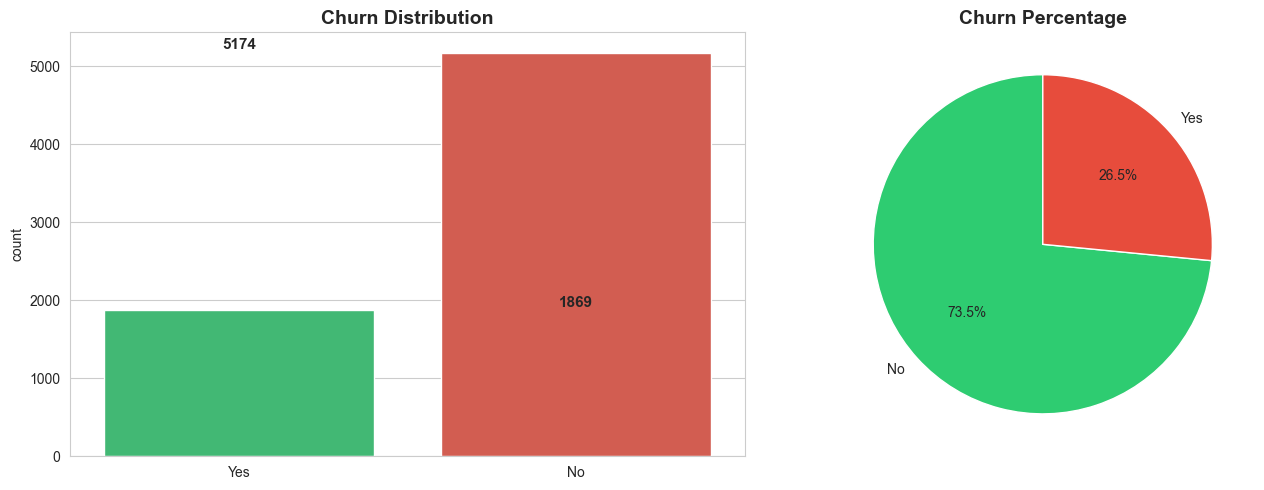

In [8]:
# === 4.1 Target Distribution ===
target_col = 'Churn Label'

print(f"\n🎯 Target Variable: {target_col}")
print(f"\nValue Counts:")
print(df[target_col].value_counts())
print(f"\nChurn Rate: {(df[target_col] == 'Yes').mean():.2%}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x=target_col, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
for i, v in enumerate(df[target_col].value_counts().values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')

# Pie chart
df[target_col].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(project_root / settings.artifacts_path / 'eda_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Correlation Analysis

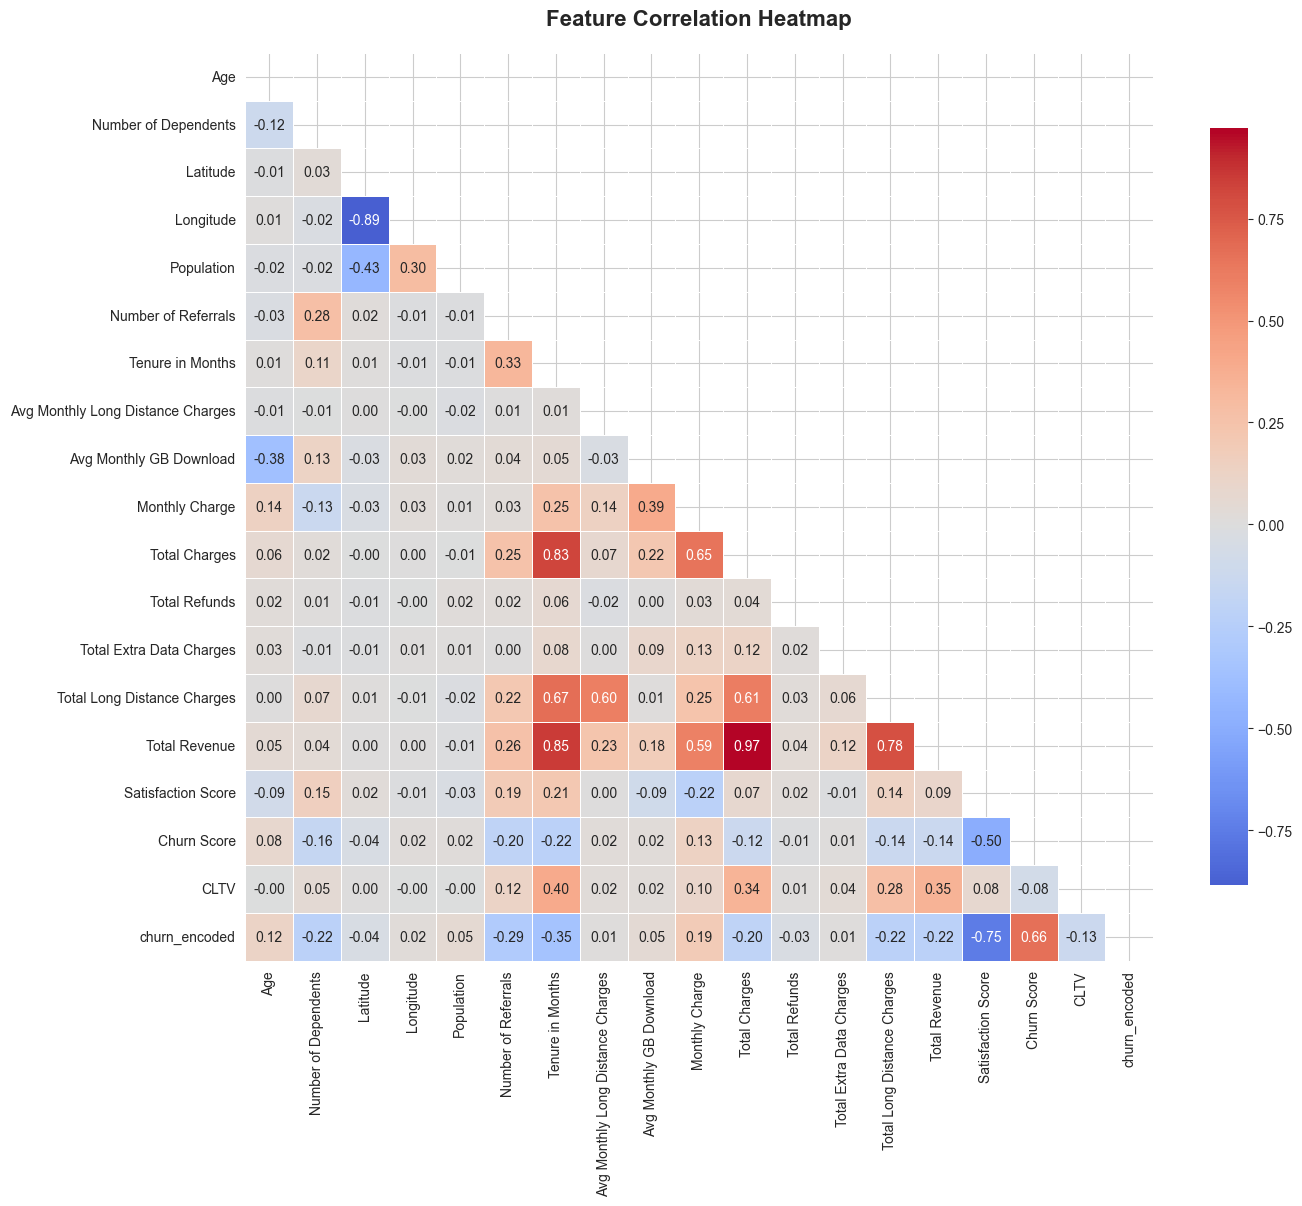


🔗 Top 10 Features Correlated with Churn:
Satisfaction Score             0.754649
Churn Score                    0.660772
Tenure in Months               0.352861
Number of Referrals            0.286540
Total Long Distance Charges    0.223756
Total Revenue                  0.223003
Number of Dependents           0.218780
Total Charges                  0.198546
Monthly Charge                 0.193356
CLTV                           0.127463
Name: churn_encoded, dtype: float64


In [14]:
# === 7.1 Correlation Heatmap (Numeric Features) ===
# Encode target for correlation
df_corr = df.copy()
df_corr['churn_encoded'] = (df_corr[target_col] == 'Yes').astype(int)

# Select numeric columns for correlation
numeric_for_corr = [c for c in numeric_cols if c in df_corr.columns] + ['churn_encoded']
corr_matrix = df_corr[numeric_for_corr].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(project_root / settings.artifacts_path / 'eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Show top correlations with target
target_corr = corr_matrix['churn_encoded'].drop('churn_encoded').abs().sort_values(ascending=False)
print("\n🔗 Top 10 Features Correlated with Churn:")
print(target_corr.head(10))

In [15]:
# === 7.2 Pairplot for Key Features (Sampled for Performance) ===
# Sample data for pairplot to avoid performance issues
sample_df = df_corr.sample(min(1000, len(df_corr)), random_state=42)

pairplot_cols = ['tenure_in_months', 'monthly_charge', 'total_charges', 'age', 'churn_encoded']
pairplot_cols = [c for c in pairplot_cols if c in sample_df.columns]

if len(pairplot_cols) >= 2:
    print(f"\n📈 Pairplot for key features (sampled: {len(sample_df)} rows)")
    sns.pairplot(sample_df[pairplot_cols], hue='churn_encoded', palette='Set1', 
                 plot_kws={'alpha': 0.6, 's': 20}, diag_kws={'bins': 20})
    plt.suptitle('Feature Relationships by Churn Status', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig(project_root / settings.artifacts_path / 'eda_pairplot.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Feature Engineering Insights

In [16]:
# === 8.1 Potential Feature Engineering Ideas ===
print("\n💡 Feature Engineering Opportunities:")

# 1. Tenure-based features
if 'tenure_in_months' in df.columns:
    print("\n   📅 Tenure-based features:")
    print("   - tenure_bin: <6mo, 6-12mo, 1-2yr, 2+yr")
    print("   - is_new_customer: tenure < 12 months")
    
    # Show tenure distribution by churn
    df['tenure_bin'] = pd.cut(df['tenure_in_months'], bins=[0, 6, 12, 24, 100], 
                              labels=['<6mo', '6-12mo', '1-2yr', '2+yr'])
    tenure_churn = df.groupby('tenure_bin')[target_col].apply(lambda x: (x == 'Yes').mean())
    print(f"   Churn rate by tenure: {tenure_churn.to_dict()}")

# 2. Charge-based features
if 'monthly_charge' in df.columns and 'total_charges' in df.columns:
    print("\n   💰 Charge-based features:")
    print("   - charge_per_month_ratio: total_charges / (tenure * monthly_charge)")
    print("   - high_value_customer: monthly_charge > 75th percentile")
    
    # Calculate and show
    df['charge_ratio'] = df['total_charges'] / (df['tenure_in_months'] * df['monthly_charge'] + 1e-6)
    print(f"   Charge ratio stats: mean={df['charge_ratio'].mean():.2f}, std={df['charge_ratio'].std():.2f}")

# 3. Service bundle features
service_cols = [c for c in df.columns if 'online' in c.lower() or 'streaming' in c.lower() or 'protection' in c.lower()]
if service_cols:
    print(f"\n   📦 Service bundle features:")
    print(f"   - num_services: count of subscribed services from {service_cols}")
    print(f"   - has_premium_bundle: multiple premium services")
    
    # Count services
    df['num_services'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
    service_churn = df.groupby('num_services')[target_col].apply(lambda x: (x == 'Yes').mean())
    print(f"   Churn rate by # services: {service_churn.to_dict()}")


💡 Feature Engineering Opportunities:

   📦 Service bundle features:
   - num_services: count of subscribed services from ['Online Security', 'Online Backup', 'Device Protection Plan', 'Streaming TV', 'Streaming Movies', 'Streaming Music']
   - has_premium_bundle: multiple premium services
   Churn rate by # services: {0: 0.2045754509458865, 1: 0.4043887147335423, 2: 0.3297413793103448, 3: 0.31573389651531153, 4: 0.2918552036199095, 5: 0.1799163179916318, 6: 0.07418397626112759}


In [17]:
# === 8.2 Interaction Insights ===
print("\n🔍 Key Interaction Insights:")

# Contract × Internet Service interaction
if 'contract' in df.columns and 'internet_service' in df.columns:
    interaction = df.groupby(['contract', 'internet_service'])[target_col].apply(lambda x: (x == 'Yes').mean()).unstack()
    print("\n   Contract × Internet Service Churn Rates:")
    print(interaction.round(3))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    sns.heatmap(interaction, annot=True, fmt='.2f', cmap='YlOrRd', center=interaction.values.mean())
    plt.title('Churn Rate: Contract × Internet Service', fontsize=14, fontweight='bold')
    plt.xlabel('Internet Service')
    plt.ylabel('Contract Type')
    plt.tight_layout()
    plt.savefig(project_root / settings.artifacts_path / 'eda_interaction_contract_internet.png', dpi=300, bbox_inches='tight')
    plt.show()


🔍 Key Interaction Insights:


## 9. Outlier Detection

In [18]:
# === 9.1 Outlier Analysis (IQR Method) ===
print("\n🔎 Outlier Detection (IQR Method):")

outlier_summary = {}
for col in key_numeric:
    if col in df.columns and df[col].notna().any():
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_pct = len(outliers) / len(df) * 100
        
        outlier_summary[col] = {
            'outlier_count': len(outliers),
            'outlier_pct': round(outlier_pct, 2),
            'bounds': f"[{lower:.1f}, {upper:.1f}]"
        }
        
        print(f"\n   {col}:")
        print(f"      Outliers: {len(outliers)} ({outlier_pct:.1f}%)")
        print(f"      IQR bounds: [{lower:.1f}, {upper:.1f}]")

# Visualize outliers for one key feature
if 'monthly_charge' in df.columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='monthly_charge', color='lightblue')
    plt.title('Monthly Charge - Outlier Detection', fontsize=14, fontweight='bold')
    plt.xlabel('Monthly Charge ($)')
    plt.tight_layout()
    plt.savefig(project_root / settings.artifacts_path / 'eda_outliers_monthly_charge.png', dpi=300, bbox_inches='tight')
    plt.show()


🔎 Outlier Detection (IQR Method):


## 10. Summary & Recommendations

In [19]:
# === 10.1 EDA Summary ===
print("\n" + "=" * 70)
print("📋 EDA SUMMARY & RECOMMENDATIONS")
print("=" * 70)

print(f"""
📊 Dataset:
   - Records: {len(df):,}
   - Features: {len(df.columns)}
   - Target: {target_col} (Churn Rate: {(df[target_col]=='Yes').mean():.2%})
   - Quality Score: {quality_report['quality_score']:.1f}/100

🎯 Key Findings:
   1. Class imbalance: {'Moderate' if 0.2 < (df[target_col]=='Yes').mean() < 0.4 else 'Severe' if (df[target_col]=='Yes').mean() < 0.2 else 'Balanced'}
   2. Top correlated features: {', '.join(target_corr.head(3).index.tolist())}
   3. High-risk segments: Month-to-Month contracts, Fiber Optic users
   4. Data quality: {'✅ Good' if quality_report['quality_score'] >= 80 else '⚠️ Needs attention'}

🔧 Recommended Actions:
   1. Handle class imbalance: Use scale_pos_weight or SMOTE
   2. Feature engineering: Create tenure bins, service bundle count
   3. Encoding: One-hot for low-cardinality, target encoding for high-cardinality
   4. Scaling: StandardScaler for numeric features
   5. Validation: Use stratified k-fold to preserve churn distribution

📁 Outputs Saved:
   - eda_target_distribution.png
   - eda_numeric_distributions.png
   - eda_categorical_distributions.png
   - eda_numeric_vs_churn.png
   - eda_categorical_vs_churn.png
   - eda_correlation_heatmap.png
   - eda_pairplot.png
   - eda_interaction_contract_internet.png
   - eda_outliers_monthly_charge.png
   - eda_missing_values.png
""")

print("✅ EDA complete! Ready for preprocessing and modeling.")


📋 EDA SUMMARY & RECOMMENDATIONS

📊 Dataset:
   - Records: 7,043
   - Features: 51
   - Target: Churn Label (Churn Rate: 26.54%)
   - Quality Score: 95.5/100

🎯 Key Findings:
   1. Class imbalance: Moderate
   2. Top correlated features: Satisfaction Score, Churn Score, Tenure in Months
   3. High-risk segments: Month-to-Month contracts, Fiber Optic users
   4. Data quality: ✅ Good

🔧 Recommended Actions:
   1. Handle class imbalance: Use scale_pos_weight or SMOTE
   2. Feature engineering: Create tenure bins, service bundle count
   3. Encoding: One-hot for low-cardinality, target encoding for high-cardinality
   4. Scaling: StandardScaler for numeric features
   5. Validation: Use stratified k-fold to preserve churn distribution

📁 Outputs Saved:
   - eda_target_distribution.png
   - eda_numeric_distributions.png
   - eda_categorical_distributions.png
   - eda_numeric_vs_churn.png
   - eda_categorical_vs_churn.png
   - eda_correlation_heatmap.png
   - eda_pairplot.png
   - eda_intera

## ✅ Next Steps

1. Run `baseline_model.ipynb` for initial model training
2. Apply recommended preprocessing based on EDA insights
3. Consider feature engineering suggestions for improved performance
4. Use stratified sampling for train/test split to handle class imbalance

---
*EDA Notebook for Telco Churn MLOps Project*